# Bees production 

### Setup

In [25]:
import numpy as np
import pandas as pd 
import utils
import matplotlib.pyplot as plt
import importlib
importlib.reload(utils)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

honey_production_df, apistox_df, inspections_on_weather_dict = utils.load_bees_datasets()
honey_production_df_copy = honey_production_df.copy()


 honey_production_df (1115, 9) : Done! 

 apistox_df (1035, 13) : Done! 

 Apiary_Information.csv (13, 4) : Done!
 HCC_Inspections.csv (2404, 11) : Done!
 Hive_Information.csv (188, 3) : Done!
 Hourly_Weather.csv (3672, 15) : Done!
 Weather_Observations.csv (1776, 4) : Done!
 Weather_Stations.csv (3, 3) : Done!

Datasets collection completed.


## Part 1: Honey production 

In [109]:
honey_production_df = honey_production_df_copy.copy()

n_states = honey_production_df.state.nunique()
utils.EDA(honey_production_df, head = n_states) #44 states
honey_production_df.drop(columns=["Unnamed: 0"], inplace=True)
for state in honey_production_df.state.unique():
    state_production = honey_production_df[honey_production_df.state == state]
    #filtering for the states that have data for all the 27 years from 1995 to 2021
    if len(state_production) < 27:
        honey_production_df.drop(state_production.index, inplace=True)


honey_production_df_copy = honey_production_df.copy()

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1115 non-null   int64  
 1   state                1115 non-null   object 
 2   colonies_number      1115 non-null   int64  
 3   yield_per_colony     1115 non-null   int64  
 4   production           1115 non-null   int64  
 5   stocks               1115 non-null   int64  
 6   average_price        1115 non-null   float64
 7   value_of_production  1115 non-null   int64  
 8   year                 1115 non-null   int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 78.5+ KB


##-------------- DESCRIBE --------------------------##
        Unnamed: 0  colonies_number  yield_per_colony    production  \
count  1115.00000      1115.000000       1115.000000  1.115000e+03   
mean    557.00000     62438

### Production Analysis 

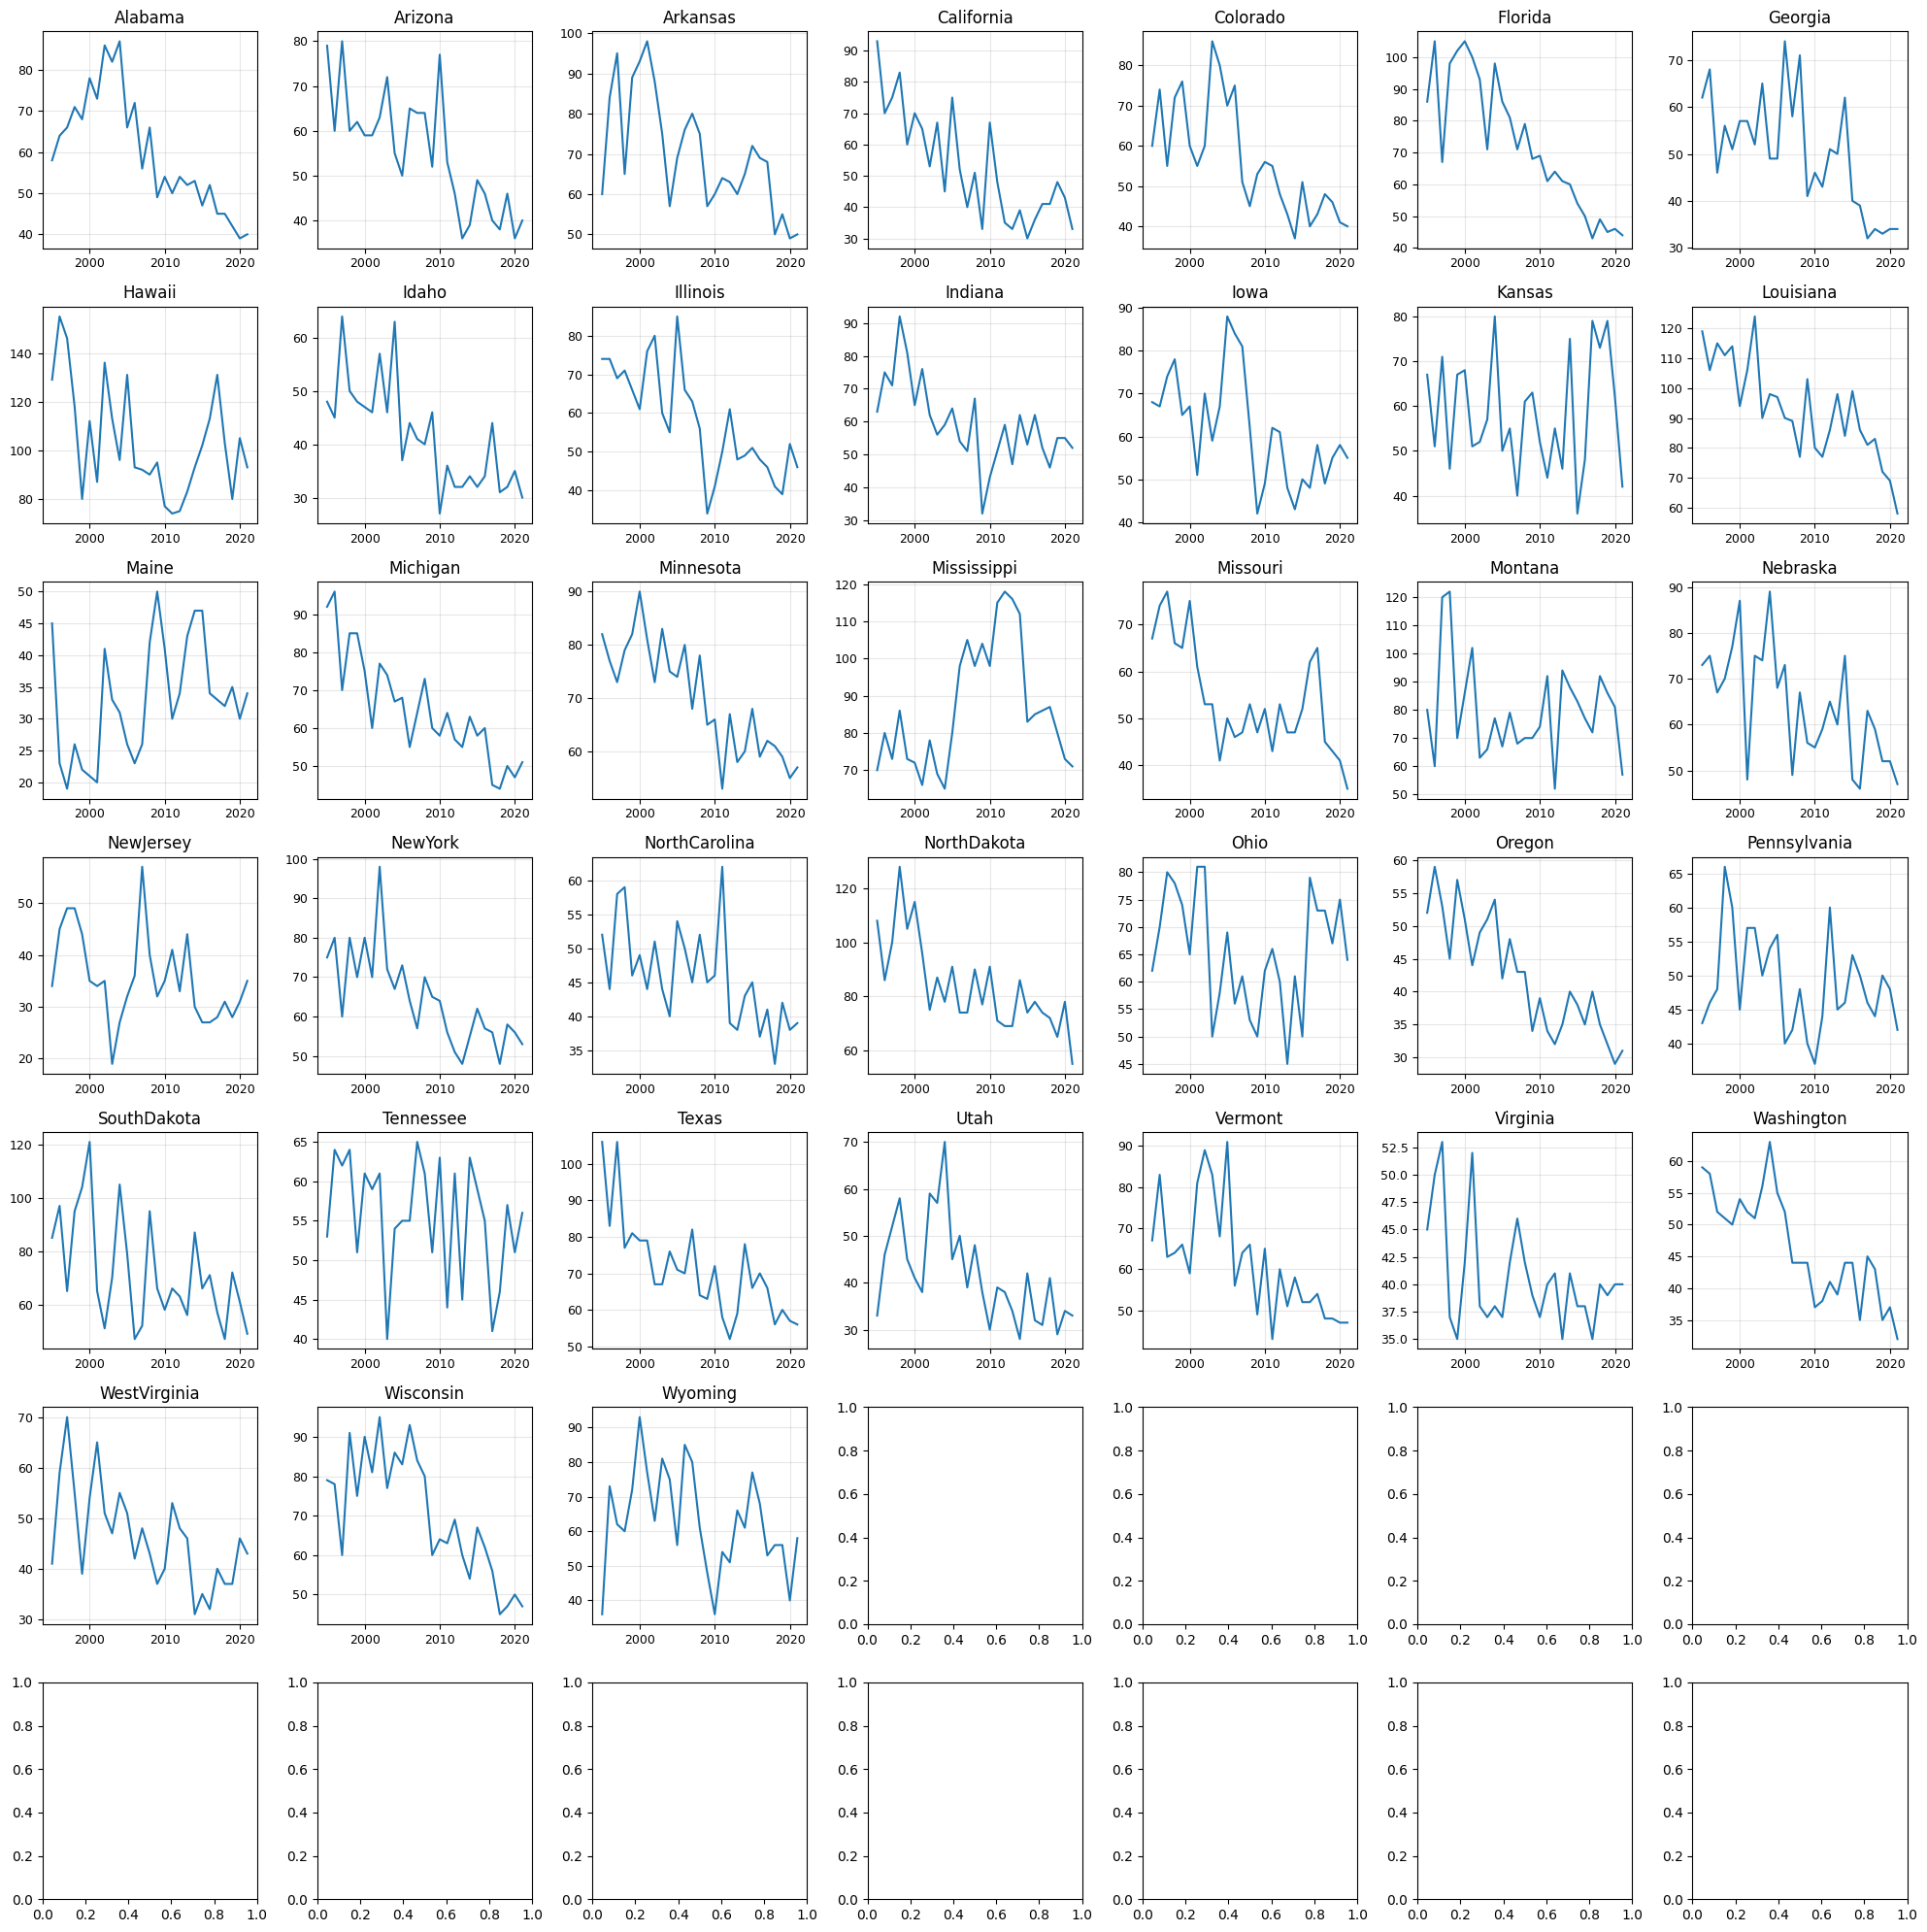

In [ ]:
utils.plot_all(honey_production_df, "state", "year", "yield_per_colony")

### Production Trend Prediction

0.8217742830203364


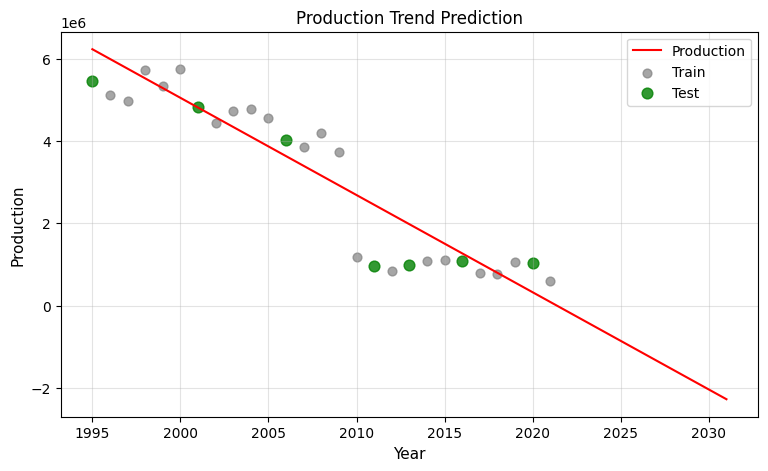

In [50]:
#setting up data
years = honey_production_df['year'].unique()
production_means = honey_production_df.groupby("year")["production"].mean()

#preparing the model
X_train, X_test, y_train, y_test = train_test_split(years.reshape(-1,1), 
                                                    production_means, 
                                                    test_size=0.25,
                                                    random_state=30)
model= LinearRegression()
model.fit(X = X_train, y = y_train)
print(model.score(X_test, y_test))

#setting up the data for predictions
future_years = np.arange(2022, 2032)
years = np.concatenate([years,future_years])
y_pred = model.predict(years.reshape(-1, 1))

#plotting the results
plt.figure(figsize=(9, 5))
plt.plot(years, y_pred, color="red", label="Production")
plt.scatter(X_train, y_train, color="grey", s=40, alpha=0.7, label="Train")
plt.scatter(X_test, y_test, color="green", s=60, alpha=0.8, label="Test")
plt.xlabel("Year", fontsize = 11)
plt.ylabel("Production", fontsize = 11)
plt.title("Production Trend Prediction")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()

### Price analysis

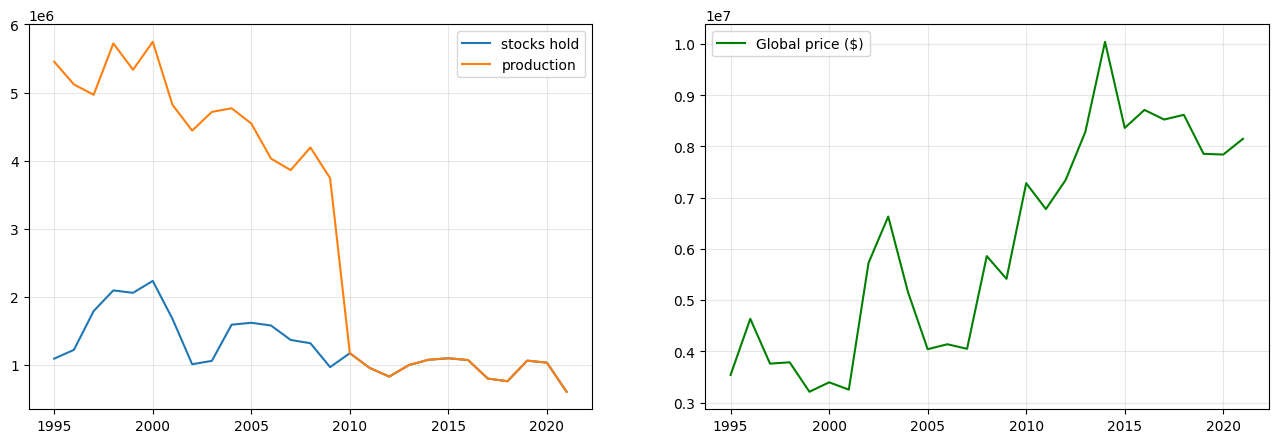

In [51]:
figure = plt.figure(figsize=(16,5))
plot1 = figure.add_subplot(1,2,1)
plot2 = figure.add_subplot(1,2,2)
plot1.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["stocks"].mean(), label = "stocks hold")
plot1.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["production"].mean(), label = "production")
plot2.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["value_of_production"].mean(), label = "Global price ($)", color = "green")
plot1.legend()
plot2.legend()
plot1.grid(alpha = 0.3)
plot2.grid(alpha = 0.3)

### Price trend Prediction 

0.7937643373061338


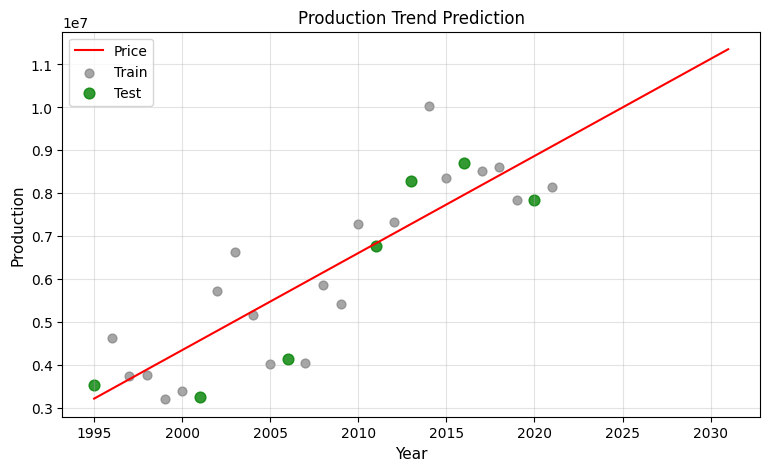

In [52]:
#setting up data
years = honey_production_df['year'].unique()
production_means = honey_production_df.groupby("year")["value_of_production"].mean()

#preparing the model
X_train, X_test, y_train, y_test = train_test_split(years.reshape(-1,1), 
                                                    production_means, 
                                                    test_size=0.25,
                                                    random_state=30)
model= LinearRegression()
model.fit(X = X_train, y = y_train)
print(model.score(X_test, y_test))

#setting up the data for predictions
future_years = np.arange(2022, 2032)
years = np.concatenate([years,future_years])
y_pred = model.predict(years.reshape(-1, 1))

#plotting the results
plt.figure(figsize=(9, 5))
plt.plot(years, y_pred, color="red", label="Price")
plt.scatter(X_train, y_train, color="grey", s=40, alpha=0.7, label="Train")
plt.scatter(X_test, y_test, color="green", s=60, alpha=0.8, label="Test")
plt.xlabel("Year", fontsize = 11)
plt.ylabel("Production", fontsize = 11)
plt.title("Production Trend Prediction")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()

## Part 2: Apistox 

In [48]:
utils.EDA(apistox_df, head = 7)

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                1035 non-null   object
 1   CID                 1035 non-null   int64 
 2   CAS                 1035 non-null   object
 3   SMILES              1035 non-null   object
 4   source              1035 non-null   object
 5   year                1035 non-null   int64 
 6   toxicity_type       1035 non-null   object
 7   herbicide           1035 non-null   int64 
 8   fungicide           1035 non-null   int64 
 9   insecticide         1035 non-null   int64 
 10  other_agrochemical  1035 non-null   int64 
 11  label               1035 non-null   int64 
 12  ppdb_level          1035 non-null   int64 
dtypes: int64(8), object(5)
memory usage: 105.2+ KB


##-------------- DESCRIBE --------------------------##
        

## Part 3: Weather Effects on Bees Health


"HCC_Inspections": contains the inspections result, together with with the percentage of requirements met. An hive is health iff all requirements are set to 1.

    - Brood: all phases of a brood are present (egg, larvae, pupae)
    - Bees: there are enough bees in the hive to manage it and defend it
    - Queen: the queen is alive, young and can reproduce
    - Food: there's enough food and source of found outside
    - Stressors: there are no stressors 
    - Space: the space is safe, clean and not in detriment 

"Hourly_Weather": contains an analysis of the weather during the recorded hour.
Important notes:

    - Degrees are in Fahrenheit
    - Wind_Gust represents the peak of speed during a recorded interval

In [26]:
table = inspections_on_weather_dict["Hourly_Weather"]
utils.EDA(table)

table

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3672 entries, 0 to 3671
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   WeatherID       3672 non-null   int64 
 1   ObsID           3672 non-null   int64 
 2   StationID       3672 non-null   int64 
 3   Temperature     3656 non-null   object
 4   Humidity        3656 non-null   object
 5   Dew_Point       3656 non-null   object
 6   Wind_Direction  3646 non-null   object
 7   Wind_Speed      3656 non-null   object
 8   Wind_Gust       3656 non-null   object
 9   Pressure        3656 non-null   object
 10  Precip          3656 non-null   object
 11  Condition       3656 non-null   object
 12  Sunrise         3672 non-null   object
 13  Sunset          3672 non-null   object
 14  Daylight_Hours  3672 non-null   object
dtypes: int64(3), object(12)
memory usage: 430.4+ KB


##-------------- DESCRIBE --------

,WeatherID,ObsID,StationID,Temperature,Humidity,Dew_Point,Wind_Direction,Wind_Speed,Wind_Gust,Pressure,Precip,Condition,Sunrise,Sunset,Daylight_Hours
0,1,1,1,54,45,33,VAR,7,0,29.54,0.0,Fair,7:07:00,19:35:00,12:28:00
1,2,2,1,52,47,32,NNW,3,0,29.56,0.0,Fair,7:07:00,19:35:00,12:28:00
2,3,3,1,51,48,32,CALM,0,0,29.57,0.0,Fair,7:07:00,19:35:00,12:28:00
3,4,4,1,48,56,33,CALM,0,0,29.57,0.0,Fair,7:07:00,19:35:00,12:28:00
4,5,5,1,46,63,34,CALM,0,0,29.58,0.0,Fair,7:07:00,19:35:00,12:28:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3667,3668,1772,3,79,25,40,N,5,0,25.60,0.0,Mostly Cloudy,6:13:00,20:37:00,14:24:00
3668,3669,1773,3,75,29,41,NNW,17,0,25.63,0.0,Partly Cloudy,6:13:00,20:37:00,14:24:00
3669,3670,1774,3,70,41,45,NNW,9,0,25.63,0.0,Partly Cloudy,6:13:00,20:37:00,14:24:00
3670,3671,1775,3,64,56,48,WSW,7,0,25.65,0.0,Partly Cloudy,6:13:00,20:37:00,14:24:00


In [27]:
apiary_part = inspections_on_weather_dict["Apiary_Information"].merge(inspections_on_weather_dict["Hive_Information"]).merge(inspections_on_weather_dict["HCC_Inspections"])
apiary_part.rename(columns={"InsptDate": "Date", }, inplace=True)
apiary_part.Date = pd.to_datetime(apiary_part.Date, format="%Y-%m-%d")

weather_part = inspections_on_weather_dict["Weather_Stations"].merge(inspections_on_weather_dict["Hourly_Weather"]).merge(inspections_on_weather_dict["Weather_Observations"])
weather_part.rename(columns={"Station_City": "City", }, inplace=True)
weather_part.Date = pd.to_datetime(weather_part.Date, format="%m/%d/%Y")

inspections_on_weather_df = weather_part.merge(apiary_part, on="Date")
inspections_on_weather_df.dropna(axis= 0, inplace=True)
inspections_on_weather_df.columns = inspections_on_weather_df.columns.map(str.upper)
inspections_on_weather_df.HEALTHY = inspections_on_weather_df.HEALTHY.map(lambda x : 1 if x == "Yes" else 0)

inspections_on_weather_df.STATE = inspections_on_weather_df.STATE.map(lambda x: "NORTHCAROLINA" if x == "NC" else "UTAH")
inspections_on_weather_df[["TEMPERATURE", "HUMIDITY", "DEW_POINT", "WIND_SPEED", "WIND_GUST", "PRESSURE", "PRECIP"]] = inspections_on_weather_df[["TEMPERATURE", "HUMIDITY", "DEW_POINT", "WIND_SPEED", "WIND_GUST", "PRESSURE", "PRECIP"]].apply(lambda x: pd.to_numeric(x.str.strip()) if x.dtype == "object" else pd.to_numeric(x))

inspections_on_weather_df_copy = inspections_on_weather_df.copy()

In [53]:
# Analysis based on the fact that, for some reason, even though the North Carolina uses a lot more pesticide in variety and quantity than
# Utah, it's honey production still stayed higher#
inspections_on_weather_df = inspections_on_weather_df_copy

inspections_on_weather_df["YEAR"] = inspections_on_weather_df.DATE.dt.year

inspections_on_weather_df["MONTH"] = inspections_on_weather_df.DATE.dt.month
inspections_on_weather_df = inspections_on_weather_df.groupby(["STATE", "YEAR", "MONTH"])[["TEMPERATURE", "HUMIDITY", "DEW_POINT", "WIND_SPEED", "WIND_GUST", "PRESSURE", "PRECIP","STRESSORS"]]
inspections_on_weather_df = inspections_on_weather_df.mean(numeric_only=True).round(2)*100

inspections_on_weather_df
result, _ = utils.random_forest(inspections_on_weather_df.drop(["STRESSORS","PRECIP"], axis = 1),inspections_on_weather_df.STRESSORS, 700)
result

Score:  0.2


,Features,Weight %
0,PRESSURE,0.194682
1,HUMIDITY,0.175652
2,WIND_GUST,0.162077
3,DEW_POINT,0.159452
4,WIND_SPEED,0.154908
5,TEMPERATURE,0.153229


### Apiatory part analysis

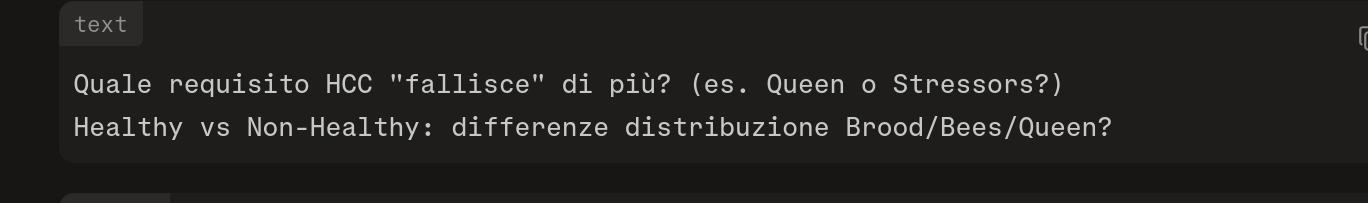

In [ ]:
failed_params = inspections_on_weather_df[inspections_on_weather_df.HEALTHY == 0][["BROOD", "BEES", "QUEEN", "FOOD", "STRESSORS", "SPACE"]]
failed_params.sum()


# failed_params = failed_params[["BROOD", "BEES", "QUEEN", "FOOD", "STRESSORS", "SPACE"]]
# failed_params 

BROOD        15102.0
BEES         18656.0
QUEEN        16018.0
FOOD         18978.0
STRESSORS     6788.0
SPACE        18001.0
dtype: float64

In [ ]:
#analisi basata sul fatto che raggruppi per stato

### Weather elements impact Classification